# Testing the FSM functions in funcs.py
Generic testing of the fill-spill-merge functiosn in funcs.py

In [1]:
%load_ext autoreload
%autoreload 2 
import sys
sys.path.append("/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/") 

import scripts.funcs as fun

import xarray as xr
import hvplot.xarray
import numpy as np

/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/scripts/funcs.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [6]:
results = fun.gridSearch(fun.fsm_xarray, x_center_of_melt = [812500.0], y_center_of_melt = [1930000, 1930000+5000], melt_magnitude=[2], 
                         post_funcs=[fun.add_center_of_mass,
                                     fun.add_GL_flux,
                                     fun.add_dem,
                                     fun.add_water_flow_over_GL])
results

  0%|          | 0/2 [00:00<?, ?it/s]

<xarray.Dataset>
Dimensions:                       (x_center_of_melt: 1, y_center_of_melt: 2,
                                   melt_magnitude: 1, x: 1024, y: 3072,
                                   bounds_index: 4)
Coordinates:
  * x_center_of_melt              (x_center_of_melt) float64 8.125e+05
  * y_center_of_melt              (y_center_of_melt) int64 1930000 1935000
  * melt_magnitude                (melt_magnitude) int64 2
  * x                             (x) float64 8e+05 8e+05 ... 8.327e+05
  * y                             (y) float64 2e+06 2e+06 ... 1.902e+06
    spatial_ref                   int64 0
    melt_width                    int64 5000
    dem_filename                  <U114 '/Users/jkingslake/Documents/science/...
    band                          int64 1
Dimensions without coordinates: bounds_index
Data variables: (12/13)
    water_depth                   (y, x, x_center_of_melt, y_center_of_melt, melt_magnitude) float64 ...
    melt                          (y, x, x_center_of_melt, y_center_of_melt, melt_magnitude) float32 dask.array<chunksize=(3072, 1024, 1, 1, 1), meta=np.ndarray>
    bounds                        (bounds_index, x_center_of_melt, y_center_of_melt, melt_magnitude) float64 ...
    x_center_of_mass              (x_center_of_melt, y_center_of_melt, melt_magnitude) float64 ...
    y_center_of_mass              (x_center_of_melt, y_center_of_melt, melt_magnitude) float64 ...
    L                             (x_center_of_melt, y_center_of_melt, melt_magnitude) float64 ...
    ...                            ...
    bfrn                          (y, x) float64 0.001691 0.001691 ... 0.0 0.0
    dem                           (y, x) float32 dask.array<chunksize=(3072, 1024), meta=np.ndarray>
    accumulation_on_grounded_ice  (x_center_of_melt, y_center_of_melt, melt_magnitude) float64 ...
    melt_on_grounded_ice          (x_center_of_melt, y_center_of_melt, melt_magnitude) float64 dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
    water_flow_over_GL            (x_center_of_melt, y_center_of_melt, melt_magnitude) float64 dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
    grounded_mask                 (y, x) int64 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
Attributes:
    AREA_OR_POINT:       Area
    PROCESSING_HISTORY:  2024-05-25 18:41:42 UTC | RichDEM v2.2.9 (hash=41503...
    TIFFTAG_DATETIME:    2024-05-25 18:41:42 UTC
    TIFFTAG_SOFTWARE:    RichDEM v2.2.9 (hash=415032db2f303721, compiled=2024...
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

In [82]:
results = fun.add_center_of_mass(results)

results = fun.add_GL_flux(results)

results = fun.add_dem(results)

results = fun.add_water_flow_over_GL(results)
 

In [98]:
results = fun.gridSearchFSM()


  0%|          | 0/2 [00:00<?, ?it/s]

In [99]:
coarsen_x, coarsen_y = 3, 3
coarse = results.coarsen(x=coarsen_x, y=coarsen_y, boundary='trim').mean()
# Include contours of the DEM, a box for the melt region and a colormap for the water depths
width , height = 1000, 500

coarse.water_depth.hvplot(x ='y', y = 'x', cmap='Blues', clim=(0,1), aspect='equal').opts(framewise=False)\
    * coarse.dem.hvplot.contour(x ='y', y = 'x',levels = 40, cmap='hot', aspect='equal').opts(framewise=False)\
    * coarse.grounded_mask.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * coarse.melt.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * coarse.hvplot.scatter(x = 'y_center_of_mass', y = 'x_center_of_mass', color = 'green', size = 400, marker = '*', aspect='equal').opts(framewise=False)

BokehModel(combine_events=True, render_bundle={'docs_json': {'da5ed20e-0e52-4b4e-b609-58ceff9265f1': {'version…

In [102]:

coarse.bfrn.hvplot(x ='y', y = 'x', cmap='Blues', aspect='equal').opts(framewise=False)


:Image   [y,x]   (bfrn)

ERROR 1: GetNoDataValue() should be called instead
[================================================= ] (99% - 0.0s - 1 threads)ERROR 6: /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/fsm_results/rema_tests/test-3-wtd.tif: Dataset does not support the AddBand() method.
ERROR 6: /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/fsm_results/rema_tests/test-3-hydrologic-surface-height.tif: Dataset does not support the AddBand() method.
/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rioxarray/_io.py:1132: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


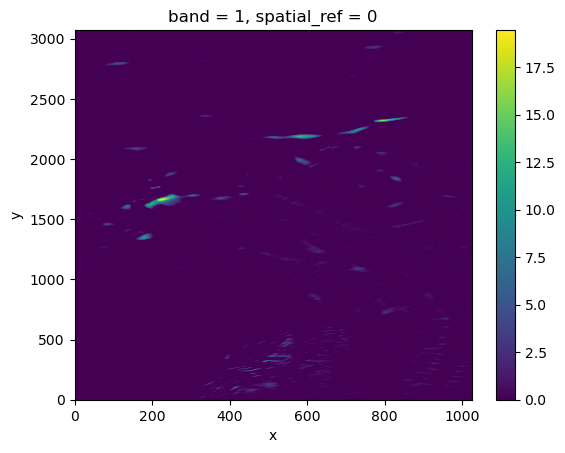

In [14]:
fun.fsm("/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif", 
        uniform_melt=0.1, 
        path_to_fsm="/Users/jkingslake/Documents/science/meltwater_routing/richdem/build/apps/rd_fill_spill_merge.exe").plot()

In [7]:
fun.fsm_xarray()

<xarray.Dataset>
Dimensions:           (x: 1024, y: 3072, bounds_index: 4)
Coordinates:
  * x                 (x) float64 8e+05 8e+05 8.001e+05 ... 8.327e+05 8.327e+05
  * y                 (y) float64 2e+06 2e+06 2e+06 ... 1.902e+06 1.902e+06
    spatial_ref       int64 0
    melt_magnitude    float64 0.1
    x_center_of_melt  float64 8.175e+05
    y_center_of_melt  float64 1.932e+06
    melt_width        int64 5000
    dem_filename      <U114 '/Users/jkingslake/Documents/science/meltwater_ro...
Dimensions without coordinates: bounds_index
Data variables:
    water_depth       (y, x) float64 ...
    melt              (y, x) float32 dask.array<chunksize=(3072, 1024), meta=np.ndarray>
    bounds            (bounds_index) float64 8.15e+05 1.93e+06 8.2e+05 1.935e+06
Attributes:
    AREA_OR_POINT:       Area
    PROCESSING_HISTORY:  2024-05-25 18:41:45 UTC | RichDEM v2.2.9 (hash=41503...
    TIFFTAG_DATETIME:    2024-05-25 18:41:45 UTC
    TIFFTAG_SOFTWARE:    RichDEM v2.2.9 (hash=415032db2f303721, compiled=2024...
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

In [2]:
fun.fsm_xarray(path_to_fsm='/Users/jkingslake/Documents/science/meltwater_routing/richdem/build/apps/rd_fill_spill_merge.exe')

/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
ERROR 1: GetNoDataValue() should be called instead
ERROR 1: GetNoDataValue() should be called instead


m Input DEM           = /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif
m Output prefix       = /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/fsm_results/rema_tests/test-3
m Surface water level = nan
m Surface water file  = /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/water_input_file_3.tif
m Ocean level         = 0
p Reading topography...
m Data width  = 1024
m Data height = 3072
m Data cells  = 3145728
p Performing bucket fill...
p Getting depression hierarchy...
m Loading DH from temp_DH
p Performing FillSpillMerge...


ERROR 6: /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/fsm_results/rema_tests/test-3-wtd.tif: Dataset does not support the AddBand() method.
ERROR 6: /Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/fsm_results/rema_tests/test-3-hydrologic-surface-height.tif: Dataset does not support the AddBand() method.
/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/rioxarray/_io.py:1132: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


Finished.
IO time   = 0.0603282 s
Calc time = 0.259467 s


ValueError: cannot reindex or align along dimension 'x' because the (pandas) index has duplicate values

In [9]:
fun.fsm('/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif', 
        melt_filename='/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/water_input_file_3.tif')

<xarray.DataArray (y: 3072, x: 1024)>
[3145728 values with dtype=float64]
Coordinates:
    band         int64 1
  * x            (x) float64 8e+05 8e+05 8.001e+05 ... 8.327e+05 8.327e+05
  * y            (y) float64 2e+06 2e+06 2e+06 ... 1.902e+06 1.902e+06 1.902e+06
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:       Area
    PROCESSING_HISTORY:  2024-05-25 18:44:54 UTC | RichDEM v2.2.9 (hash=41503...
    TIFFTAG_DATETIME:    2024-05-25 18:44:54 UTC
    TIFFTAG_SOFTWARE:    RichDEM v2.2.9 (hash=415032db2f303721, compiled=2024...
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0